# Exploring the dowhy library

1. Running dowhy's tutorial from https://github.com/py-why/dowhy
2. Running commands on IHDP data

In [ ]:
pip install dowhy

In [2]:
from dowhy import CausalModel
import dowhy.datasets
import pandas as pd

## 1. Run the tutorial code

In [17]:
# Load some sample data
data = dowhy.datasets.linear_dataset(
    beta=10,
    num_common_causes=5,
    num_instruments=2,
    num_samples=10000,
    treatment_is_binary=True)

In [18]:
for k,v in data.items():
    if k!='df':
        print("---")
        print(k)
        print(v)

---
treatment_name
['v0']
---
outcome_name
y
---
common_causes_names
['W0', 'W1', 'W2', 'W3', 'W4']
---
instrument_names
['Z0', 'Z1']
---
effect_modifier_names
[]
---
frontdoor_variables_names
[]
---
dot_graph
digraph {v0->y;W0-> v0; W1-> v0; W2-> v0; W3-> v0; W4-> v0;Z0-> v0; Z1-> v0;W0-> y; W1-> y; W2-> y; W3-> y; W4-> y;}
---
gml_graph
graph[directed 1node[ id "y" label "y"]node[ id "W0" label "W0"] node[ id "W1" label "W1"] node[ id "W2" label "W2"] node[ id "W3" label "W3"] node[ id "W4" label "W4"]node[ id "Z0" label "Z0"] node[ id "Z1" label "Z1"]node[ id "v0" label "v0"]edge[source "v0" target "y"]edge[ source "W0" target "v0"] edge[ source "W1" target "v0"] edge[ source "W2" target "v0"] edge[ source "W3" target "v0"] edge[ source "W4" target "v0"]edge[ source "Z0" target "v0"] edge[ source "Z1" target "v0"]edge[ source "W0" target "y"] edge[ source "W1" target "y"] edge[ source "W2" target "y"] edge[ source "W3" target "y"] edge[ source "W4" target "y"]]
---
ate
10.0002158884

In [19]:
data["df"].head(2)

,Z0,Z1,W0,W1,W2,W3,W4,v0,y
0,0.0,0.914249,0.305674,0.660125,0.313448,-1.450131,-0.476626,True,10.056889
1,0.0,0.383697,-0.305898,0.149819,0.009363,-0.303104,0.827477,True,12.499359


### I. Create a causal model from the data and given graph.

In [4]:
model = CausalModel(
    data=data["df"],
    treatment=data["treatment_name"],
    outcome=data["outcome_name"],
    graph=data["gml_graph"])  # Or alternatively, as nx.DiGraph

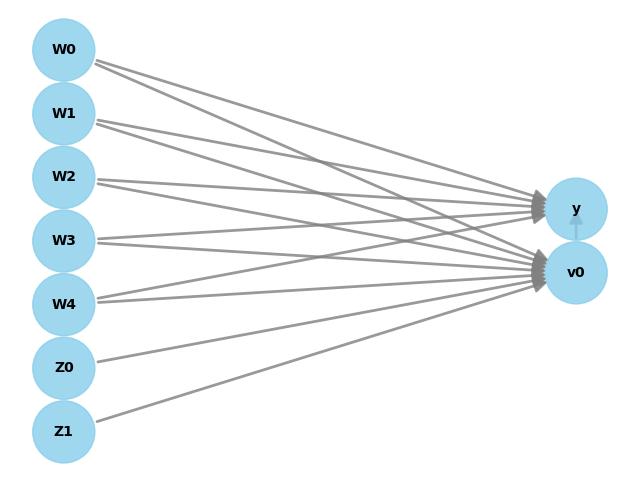

In [24]:
model.view_model()

### II. Identify causal effect and return target estimands

Identification can be achieved without access to the data, acccesing only the graph. This results in an expression to be computed. This expression can then be evaluated using the available data in the estimation step. It is important to understand that these are orthogonal steps.


In [ ]:

identified_estimand = model.identify_effect()

In [25]:
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d                       
─────(E[y|W1,W2,W4,W3,W0])
d[v₀]                     
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W1,W2,W4,W3,W0,U) = P(y|v0,W1,W2,W4,W3,W0)

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                              -1⎤
 ⎢    d        ⎛    d          ⎞  ⎥
E⎢─────────(y)⋅⎜─────────([v₀])⎟  ⎥
 ⎣d[Z₁  Z₀]    ⎝d[Z₁  Z₀]      ⎠  ⎦
Estimand assumption 1, As-if-random: If U→→y then ¬(U →→{Z1,Z0})
Estimand assumption 2, Exclusion: If we remove {Z1,Z0}→{v0}, then ¬({Z1,Z0}→y)

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!



### III. Estimate the target estimand using a statistical method.

You can input additional parameters to the estimate_effect method. For instance, to estimate the effect on any subset of the units, you can specify the “target_units” parameter which can be a string (“ate”, “att”, or “atc”), lambda function that filters rows of the data frame, or a new dataframe on which to compute the effect. You can also specify “effect modifiers” to estimate heterogeneous effects across these variables. See help(CausalModel.estimate_effect).


In [ ]:
estimate = model.estimate_effect(identified_estimand,
                                 method_name="backdoor.propensity_score_matching")

In [26]:
print(estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d                       
─────(E[y|W1,W2,W4,W3,W0])
d[v₀]                     
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W1,W2,W4,W3,W0,U) = P(y|v0,W1,W2,W4,W3,W0)

## Realized estimand
b: y~v0+W1+W2+W4+W3+W0
Target units: ate

## Estimate
Mean value: 10.001135078688227



In [29]:
# Causal effect on the control group (ATC)
causal_estimate_att = model.estimate_effect(identified_estimand,
        method_name="backdoor.propensity_score_stratification",
        target_units = "atc")
print(causal_estimate_att)
print("Causal Estimate is " + str(causal_estimate_att.value))

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d                       
─────(E[y|W1,W2,W4,W3,W0])
d[v₀]                     
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W1,W2,W4,W3,W0,U) = P(y|v0,W1,W2,W4,W3,W0)

## Realized estimand
b: y~v0+W1+W2+W4+W3+W0
Target units: atc

## Estimate
Mean value: 9.927958145896428

Causal Estimate is 9.927958145896428


### IV. Refute the obtained estimate using multiple robustness checks.

Let us now look at ways of refuting the estimate obtained. Refutation methods provide tests that every correct estimator should pass. So if an estimator fails the refutation test (p-value is <0.05), then it means that there is some problem with the estimator.

Note that we cannot verify that the estimate is correct, but we can reject it if it violates certain expected behavior (this is analogous to scientific theories that can be falsified but not proven true). The below refutation tests are based on either

1. Invariant transformations: changes in the data that should not change the estimate. Any estimator whose result varies significantly between the original data and the modified data fails the test;

2. Random Common Cause

3. Data Subset

4. Nullifying transformations: after the data change, the causal true estimate is zero. Any estimator whose result varies significantly from zero on the new data fails the test.

5. Placebo Treatment

In [34]:
refute_results = model.refute_estimate(identified_estimand, estimate,
                                       method_name="random_common_cause")
print(refute_results)

Refute: Add a random common cause
Estimated effect:10.001135078688227
New effect:9.941993834112367
p value:0.52



In [35]:
res_placebo=model.refute_estimate(identified_estimand, estimate,
        method_name="placebo_treatment_refuter", show_progress_bar=True, placebo_type="permute")
print(res_placebo)

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refute: Use a Placebo Treatment
Estimated effect:10.001135078688227
New effect:-0.011212317467514417
p value:0.9



In [36]:
res_subset=model.refute_estimate(identified_estimand, estimate,
        method_name="data_subset_refuter", show_progress_bar=True, subset_fraction=0.9)
print(res_subset)

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refute: Use a subset of data
Estimated effect:10.001135078688227
New effect:10.04142338392303
p value:0.46



#### Without using a graph


In [31]:
model= CausalModel(
        data=data["df"],
        treatment=data["treatment_name"],
        outcome=data["outcome_name"],
        common_causes=data["common_causes_names"],
        effect_modifiers=data["effect_modifier_names"])

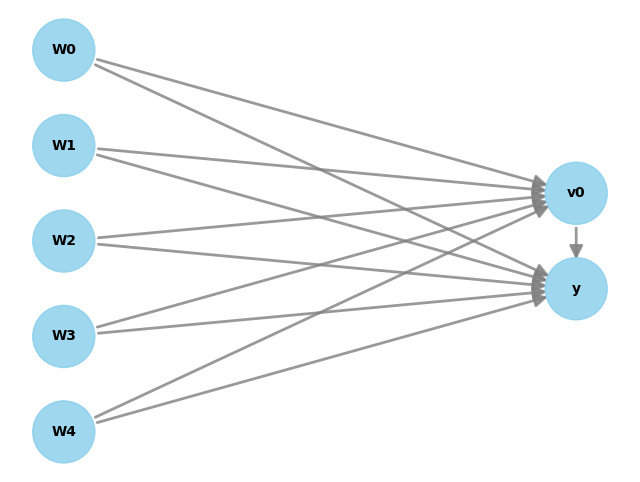

In [32]:
model.view_model()

## 2. Using the IHDP data

In [5]:
ihdp_data = pd.read_csv("../data/inputs/ihdp_data.csv")

In [6]:
model= CausalModel(
        data=ihdp_data,
        treatment="treatment",
        outcome="y_factual",
        common_causes=[f'x{i}' for i in range(1, 26)],
#         effect_modifiers=[]
)

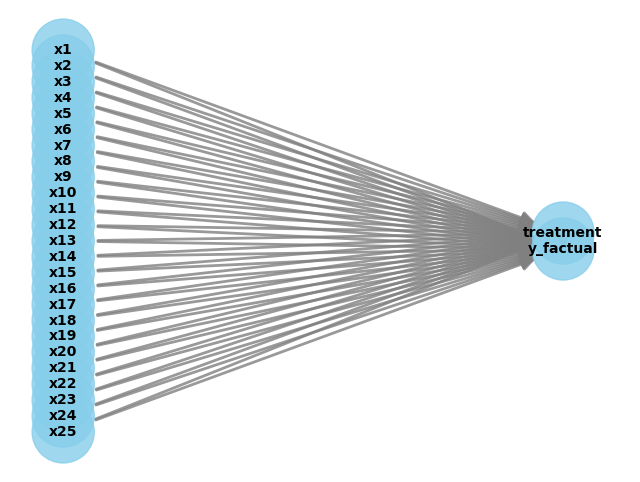

In [7]:
model.view_model()

In [8]:
identified_estimand = model.identify_effect()
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                        
────────────(E[y_factual|x19,x20,x8,x12,x15,x6,x2,x18,x14,x23,x10,x1,x9,x11,x7
d[treatment]                                                                  

                                       
,x5,x24,x4,x3,x13,x21,x25,x22,x17,x16])
                                       
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→y_factual then P(y_factual|treatment,x19,x20,x8,x12,x15,x6,x2,x18,x14,x23,x10,x1,x9,x11,x7,x5,x24,x4,x3,x13,x21,x25,x22,x17,x16,U) = P(y_factual|treatment,x19,x20,x8,x12,x15,x6,x2,x18,x14,x23,x10,x1,x9,x11,x7,x5,x24,x4,x3,x13,x21,x25,x22,x17,x16)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!



From Gemini

3. Estimate: estimate_effect()
What you do: You choose a statistical method (e.g., backdoor.linear_regression, backdoor.propensity_score_matching, backdoor.g_formula) to calculate the causal effect based on the identified estimand and your data.
What it means: This is where the actual numbers come out.

Output: You'll get a CausalEstimate object. When you print it, you'll see:
```
*** Causal Estimate ***
## Data Estimate
# Causal Effect (ATE)
-0.12345
# Standard Error
0.05678
# p-value
0.0210
# Confidence Interval
[-0.23456, -0.01234]
```

Interpretation:

Causal Effect (ATE): -0.12345: This is your point estimate of the Average Treatment Effect.

For binary treatment (like IHDP): This value represents the average difference in the outcome (y_factual - cognitive score) between the treated group and the control group, after adjusting for the specified common causes.

Example: If your treatment is 0 (control) or 1 (intervention), and the outcome is cognitive score, then a value of -0.12345 means that, on average, receiving the intervention leads to a decrease of 0.12345 units in cognitive score compared to not receiving it, all else being equal (i.e., holding confounders constant). For IHDP, you'd likely expect a positive effect, so a negative value here might suggest issues or that you're looking at a subgroup where the effect is negative.

Standard Error: A measure of the variability of your estimate. Smaller is better.

p-value: Indicates the probability of observing an effect as large or larger than your estimate if there were no true causal effect (i.e., if the null hypothesis of zero effect were true).

Interpretation: If p < 0.05 (a common threshold), you typically consider the effect statistically significant, meaning it's unlikely to have occurred by chance.

Confidence Interval: Provides a range within which the true causal effect is likely to lie (e.g., 95% of the time).

Interpretation: If the confidence interval does not include zero, it reinforces the idea that the effect is statistically significant. If it does include zero, then you cannot rule out the possibility of no effect.

In [48]:
estimate = model.estimate_effect(identified_estimand,
                                 method_name="backdoor.propensity_score_matching")
print(estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                        
────────────(E[y_factual|x13,x8,x19,x2,x1,x20,x5,x24,x15,x7,x21,x22,x3,x12,x18
d[treatment]                                                                  

                                       
,x4,x11,x16,x25,x14,x9,x6,x10,x17,x23])
                                       
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→y_factual then P(y_factual|treatment,x13,x8,x19,x2,x1,x20,x5,x24,x15,x7,x21,x22,x3,x12,x18,x4,x11,x16,x25,x14,x9,x6,x10,x17,x23,U) = P(y_factual|treatment,x13,x8,x19,x2,x1,x20,x5,x24,x15,x7,x21,x22,x3,x12,x18,x4,x11,x16,x25,x14,x9,x6,x10,x17,x23)

## Realized estimand
b: y_factual~treatment+x13+x8+x19+x2+x1+x20+x5+x24+x15+x7+x21+x22+x3+x12+x18+x4+x11+x16+x25+x14+x9+x6+x10+x17+x23
Target units: ate

## Estimate
Mean va

#### I think this means

Receiving the intervention leads to an increase of around 4 units in cognitive score compared to not receiving it, all else being equal (i.e., holding confounders constant).

In [53]:
# Causal effect on the control group (ATC)
causal_estimate_att = model.estimate_effect(identified_estimand,
        method_name="backdoor.propensity_score_stratification",
        target_units = "atc")
print("Causal Estimate is " + str(causal_estimate_att.value))

Causal Estimate is 3.9678207002391352


In [54]:
# Causal effect on the control group (ATE)
causal_estimate_ate = model.estimate_effect(identified_estimand,
        method_name="backdoor.propensity_score_stratification",
        target_units = "ate")
print("Causal Estimate is " + str(causal_estimate_ate.value))

Causal Estimate is 3.9324551499457203


In [55]:
# Causal effect on the control group (ATT)
causal_estimate_att = model.estimate_effect(identified_estimand,
        method_name="backdoor.propensity_score_stratification",
        target_units = "att")
print("Causal Estimate is " + str(causal_estimate_att.value))

Causal Estimate is 3.836421867035145


In [50]:
refute_results = model.refute_estimate(identified_estimand, estimate,
                                       method_name="random_common_cause")
print(refute_results)

Refute: Add a random common cause
Estimated effect:3.9791388232170393
New effect:3.97913882321704
p value:1.0



In [51]:
res_placebo=model.refute_estimate(identified_estimand, estimate,
        method_name="placebo_treatment_refuter", show_progress_bar=True, placebo_type="permute")
print(res_placebo)

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refute: Use a Placebo Treatment
Estimated effect:3.9791388232170393
New effect:0.02115168270051015
p value:0.8799999999999999



In [52]:
res_subset=model.refute_estimate(identified_estimand, estimate,
        method_name="data_subset_refuter", show_progress_bar=True, subset_fraction=0.9)
print(res_subset)

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refute: Use a subset of data
Estimated effect:3.9791388232170393
New effect:3.995548171746199
p value:0.72

